# A/B Testing
- Simulate experiment data
- Compute conversion rates, uplift, confidence intervals
- Perform two-proportion z-test and chi-square test
- Plot conversion rates with 95% CIs

Requirements: pandas, numpy, matplotlib, statsmodels, scipy

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency, norm
import math

In [2]:
# Data

np.random.seed(1234)

# 1) Simulate dataset
def simulate_ab(n_control=5000, n_treatment=5000, 
                p_control=0.05, p_treatment=0.06, 
                seed=42):

    rng = np.random.default_rng(seed)

    control = rng.binomial(1, p_control, size=n_control)
    treatment = rng.binomial(1, p_treatment, size=n_treatment)

    df = pd.DataFrame({
        'user_id': np.arange(n_control + n_treatment),
        'group': ['control']*n_control + ['treatment']*n_treatment,
        'converted': np.concatenate([control, treatment])
    })

    return df

In [3]:
# Computing
# 2) Summary stats, conversion rates
def summarize(df):
    summary = df.groupby('group')['converted'].agg(['sum','count']).reset_index()
    summary['cr'] = summary['sum'] / summary['count']
    return summary

# 3) Two-proportion z-test
def two_prop_test(summary):
    count = summary['sum'].values
    nobs = summary['count'].values
    stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    return stat, pval

# 4) Chi-square test on contingency table
def chi2_test(df):
    table = pd.crosstab(df['group'], df['converted'])
    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, table, expected

# 5) Confidence intervals for proportions (normal approx)
def proportion_ci(count, n, alpha=0.05):
    p = count / n
    z = norm.ppf(1 - alpha/2)
    se = math.sqrt(p*(1-p)/n)
    lower = p - z*se
    upper = p + z*se
    return max(0, lower), min(1, upper), se

# 6) CI for difference in proportions (normal approx)
def diff_prop_ci(p0, n0, p1, n1, alpha=0.05):
    diff = p1 - p0
    z = norm.ppf(1 - alpha/2)
    se = math.sqrt(p0*(1-p0)/n0 + p1*(1-p1)/n1)
    lower = diff - z*se
    upper = diff + z*se
    return diff, lower, upper, se

# 7) Uplift (absolute and relative)
def uplift_metrics(p0, p1):
    abs_uplift = p1 - p0
    rel_uplift = (p1 - p0) / p0 if p0 != 0 else float('inf')
    return abs_uplift, rel_uplift

In [4]:
#Plotting
# 8) Plot conversion rates with 95% CI
def plot_cr(summary):
    groups = summary['group']
    crs = summary['cr']
    lowers = []
    uppers = []
    for _, row in summary.iterrows():
        lo, up, _ = proportion_ci(row['sum'], row['count'])
        lowers.append(lo)
        uppers.append(up)
    errs = [crs - np.array(lowers), np.array(uppers) - crs]
    plt.figure(figsize=(6,4))
    plt.bar(groups, crs, yerr=errs, capsize=8, color=['#4C72B0','#55A868'])
    plt.ylabel('Conversion rate')
    plt.title('Conversion rate by group (95% CI)')
    plt.ylim(0, max(uppers)*1.6)
    for i, v in enumerate(crs):
        plt.text(i, v + 0.001, f'{v:.3%}', ha='center')
    plt.tight_layout()
    plt.show()

 
...............................................................
Summary:
       group  sum  count      cr
0    control  243   5000  0.0486
1  treatment  309   5000  0.0618
 
...............................................................
Two-proportion z-test: stat=-2.890, p-value=0.0039 

Chi-square test: chi2=8.101, p-value=0.0044 

Conversion rate 95% CIs:
  control: 4.860% (95% CI: 4.264% — 5.456%)
  treatment: 6.180% (95% CI: 5.513% — 6.847%) 

Difference in proportions (treatment - control): 0.0132 

95% CI for difference: [0.0043, 0.0221] 

Absolute uplift: 1.3200%  — Relative uplift: 27.16% 



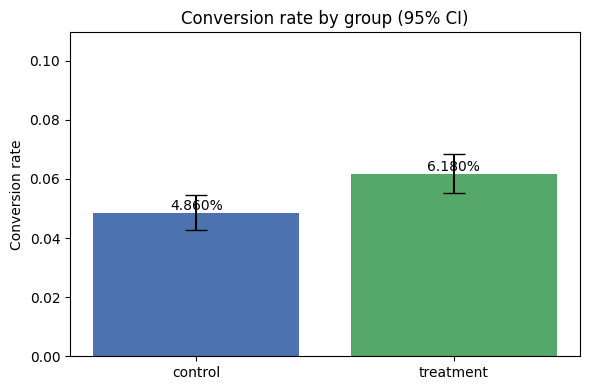

...............................................................
Interpretation:
  The difference is statistically significant (z p=0.0039). Treatment changed conversion rate.
  Note: statistical significance does not always imply business significance. Consider expected revenue impact and cost of actions.
  If you want uncertainty for ML-based estimators, consider applying bootstrap, quantile regression, or conformal prediction.


In [5]:

# 9) Run demo
def main():
    # simulate
    df = simulate_ab(n_control=5000, n_treatment=5000, p_control=0.05, p_treatment=0.06)
    summary = summarize(df)
    print(" \n...............................................................")
    print('Summary:')
    print(summary[['group','sum','count','cr']])

    # tests
    z_stat, z_p = two_prop_test(summary)
    chi2, chi_p, table, expected = chi2_test(df)
    print(" \n...............................................................")
    print(f'Two-proportion z-test: stat={z_stat:.3f}, p-value={z_p:.4f} \n')
    print(f'Chi-square test: chi2={chi2:.3f}, p-value={chi_p:.4f} \n')

    # CIs and uplift
    row0 = summary.iloc[0]
    row1 = summary.iloc[1]
    lo0, up0, se0 = proportion_ci(row0['sum'], row0['count'])
    lo1, up1, se1 = proportion_ci(row1['sum'], row1['count'])
    diff, diff_lo, diff_up, diff_se = diff_prop_ci(row0['cr'], row0['count'], row1['cr'], row1['count'])
    abs_uplift, rel_uplift = uplift_metrics(row0['cr'], row1['cr'])

    print('Conversion rate 95% CIs:')
    print(f"  {row0['group']}: {row0['cr']:.3%} (95% CI: {lo0:.3%} — {up0:.3%})")
    print(f"  {row1['group']}: {row1['cr']:.3%} (95% CI: {lo1:.3%} — {up1:.3%}) \n")
    print(f'Difference in proportions (treatment - control): {diff:.4f} \n')
    print(f'95% CI for difference: [{diff_lo:.4f}, {diff_up:.4f}] \n')
    print(f'Absolute uplift: {abs_uplift:.4%}  — Relative uplift: {rel_uplift:.2%} \n')

    # plot
    plot_cr(summary)

    # Business interpretation
    alpha = 0.05
    print("...............................................................")
    print('Interpretation:')
    if z_p < alpha:
        print(f'  The difference is statistically significant (z p={z_p:.4f}). Treatment changed conversion rate.')
    else:
        print(f'  No statistically significant difference (z p={z_p:.4f}).')

    print('  Note: statistical significance does not always imply business significance. Consider expected revenue impact and cost of actions.')
    print('  If you want uncertainty for ML-based estimators, consider applying bootstrap, quantile regression, or conformal prediction.')

    return {
        'summary': summary,
        'z_test': (z_stat, z_p),
        'chi2_test': (chi2, chi_p),
        'diff_ci': (diff, diff_lo, diff_up)
    }

if __name__ == "__main__":
    results = main()

In [6]:
"""
Summary:
       group  sum  count      cr
0    control  257   5000  0.0514
1  treatment  291   5000  0.0582
 

Two-proportion z-test: stat=-1.494, p-value=0.1352 

Chi-square test: chi2=2.102, p-value=0.1471 

Conversion rate 95% CIs:
  control: 5.140% (95% CI: 4.528% — 5.752%)
  treatment: 5.820% (95% CI: 5.171% — 6.469%) 

Difference in proportions (treatment - control): 0.0068 

95% CI for difference: [-0.0021, 0.0157] 

Absolute uplift: 0.6800%  — Relative uplift: 13.23% """

'\nSummary:\n       group  sum  count      cr\n0    control  257   5000  0.0514\n1  treatment  291   5000  0.0582\n\n\nTwo-proportion z-test: stat=-1.494, p-value=0.1352 \n\nChi-square test: chi2=2.102, p-value=0.1471 \n\nConversion rate 95% CIs:\n  control: 5.140% (95% CI: 4.528% — 5.752%)\n  treatment: 5.820% (95% CI: 5.171% — 6.469%) \n\nDifference in proportions (treatment - control): 0.0068 \n\n95% CI for difference: [-0.0021, 0.0157] \n\nAbsolute uplift: 0.6800%  — Relative uplift: 13.23% '

Although the treatment shows a positive absolute uplift of 0.68 percentage points (13.23% relative), the effect is not statistically significant at the 5% level.
The 95% confidence interval for the difference includes zero, indicating that the observed improvement may be due to sampling variability.
This suggests either the effect size is too small or the experiment is underpowered. A power analysis would help determine the required sample size to reliably detect a 0.68pp improvement.